In [1]:
import numpy as np
import cv2

## List all files

In [2]:
import pathlib
import os

files_path = pathlib.Path('/home/perezfo/Documents/channel_0/')

# https://stackoverflow.com/questions/58312120/how-to-naturally-sort-pathlib-objects-in-python
files_list = sorted(pathlib.Path(files_path).glob('*.jpg'), key=lambda path: int(path.stem))

## Reading a file and applying a median blur filter

In [3]:
img = cv2.imread(str(files_list[0]))

cv2.imshow('Original image',img)
cv2.waitKey(0)
cv2.destroyAllWindows()

Cripping the image

In [4]:
img = img[100:370, 200:470]

cv2.imshow('Cropped image',img)
cv2.waitKey(0)
cv2.destroyAllWindows()

Converting to grayscale and applying median blur filter

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_blur = cv2.medianBlur(gray, 5)

cv2.imshow('Cropped Median Blur',img_blur)
cv2.waitKey(0)
cv2.destroyAllWindows()

## Detecting the circles

Now we can detect circles using the circle Hough Transform

https://en.wikipedia.org/wiki/Circle_Hough_Transform

In [6]:
circles = cv2.HoughCircles(img_blur,
                           cv2.HOUGH_GRADIENT,
                           1,
                           minDist=30,
                           param1=20,
                           param2=10,
                           minRadius=10,
                           maxRadius=15
                          )[0]

In [7]:
circles.shape

(25, 3)

In [8]:
circles

array([[140.5 , 132.5 ,  11.1 ],
       [ 37.5 ,  88.5 ,  11.1 ],
       [190.5 ,  84.5 ,  11.8 ],
       [ 92.5 , 140.5 ,  11.6 ],
       [ 95.5 , 183.5 ,  11.1 ],
       [240.5 , 134.5 ,  11.3 ],
       [ 38.5 , 136.5 ,  10.5 ],
       [187.5 ,  40.5 ,  11.8 ],
       [242.5 , 230.5 ,  11.8 ],
       [140.5 , 231.5 ,  11.6 ],
       [194.5 , 228.5 ,  11.1 ],
       [242.5 , 184.5 ,  12.  ],
       [142.5 , 184.5 ,  11.6 ],
       [136.5 ,  83.5 ,  11.8 ],
       [137.5 ,  35.5 ,  11.8 ],
       [ 37.5 , 182.5 ,  11.8 ],
       [ 86.5 ,  38.5 ,  11.8 ],
       [ 42.5 , 233.5 ,  10.35],
       [192.5 , 138.5 ,  11.8 ],
       [ 91.5 , 229.5 ,  12.5 ],
       [ 40.5 ,  35.5 ,  11.6 ],
       [200.5 , 181.5 ,  12.1 ],
       [ 88.5 ,  86.5 ,  10.5 ],
       [239.5 ,  91.5 ,  11.3 ],
       [239.5 ,  45.5 ,  11.8 ]], dtype=float32)

In [9]:
# Draw detected circles
circles = np.uint16(np.around(circles))

for n, i in enumerate(circles):

    # outer circle
    ## cv2.circle(image, center_coordinates, radius, color, thickness)
    cv2.circle(img, (i[0], i[1]), i[2], (0, 0, 0), 2)
    # inner circle
    cv2.circle(img, (i[0], i[1]), 1, (0, 0, 255), 2)
    # text
    cv2.putText(img, "{}".format(n + 1), (i[0], i[1]), cv2.FONT_HERSHEY_PLAIN, 1.0, (255, 255, 255), 1)

        
cv2.imshow('Detected circles',img)
cv2.waitKey(0)
cv2.destroyAllWindows()

## Sorting the circles

In [10]:
circles = np.round(circles).astype("int")
circles = sorted(circles, key=lambda v: [v[1], v[0]])

NUM_COLS = 5

sorted_rows = []
for k in range(0, len(circles), NUM_COLS):
    row = circles[k:k+NUM_COLS]
    sorted_rows.extend(sorted(row, key=lambda v: v[0]))

circles = sorted_rows

In [11]:
img = cv2.imread(str(files_list[0]))
img = img[100:370, 200:470]


circles = np.uint16(np.around(circles))

for n, i in enumerate(circles):

    # outer circle
    ## cv2.circle(image, center_coordinates, radius, color, thickness)
    cv2.circle(img, (i[0], i[1]), i[2], (0, 0, 0), 1)

    # inner circle
    cv2.circle(img, (i[0], i[1]), 1, (0, 0, 255), 1)

    cv2.putText(img, "{}".format(n + 1), (i[0], i[1]), cv2.FONT_HERSHEY_PLAIN, 1.0, (255, 255, 255), 1)

        
cv2.imshow('Detected circles (sorted)',img)
cv2.waitKey(0)
cv2.destroyAllWindows()

## Getting image of one circle

In [12]:
img = cv2.imread(str(files_list[0]))
img = img[100:370, 200:470]

n = 10

x = circles[n-1][0]
y = circles[n-1][1]
r = circles[n-1][2]

img = img[y-r:y+r,x-r:x+r]

mask = False
if mask:
    # create a mask
    ## https://stackoverflow.com/questions/50697179/opencv-and-python-how-croped-circle-area-only
    
    mask = np.full((img.shape[0], img.shape[1]), 0, dtype=np.uint8) 
    # create circle mask, center, radius, fill color, size of the border
    cv2.circle(mask,(r,r), r, (255,255,255),-1)
    # get only the inside pixels
    fg = cv2.bitwise_or(img, img, mask=mask)

    mask = cv2.bitwise_not(mask)
    background = np.full(img.shape, 255, dtype=np.uint8)
    bk = cv2.bitwise_or(background, background, mask=mask)
    img = cv2.bitwise_or(fg, bk)
    

cv2.imshow('circle1', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

## Altogether

In [13]:
def sort_circles(circles):
        # https://stackoverflow.com/questions/61741434/opencv-sorting-array-of-circles
        circles = np.round(circles).astype("int")
        circles = sorted(circles, key=lambda v: [v[1], v[0]])

        NUM_COLS = 5

        sorted_rows = []
        for k in range(0, len(circles), NUM_COLS):
            row = circles[k:k+NUM_COLS]
            sorted_rows.extend(sorted(row, key=lambda v: v[0]))

        return sorted_rows

        
def plot_detected_circles(img, circles):
    # Draw detected circles
    if circles is not None:
        circles = np.uint16(np.around(circles))

        for n, i in enumerate(circles):

            # outer circle
            ## cv2.circle(image, center_coordinates, radius, color, thickness)
            cv2.circle(img, (i[0], i[1]), i[2], (0, 0, 0), 2)

            # inner circle
            cv2.circle(img, (i[0], i[1]), 1, (0, 0, 255), 2)

            cv2.putText(img, "{}".format(n + 1), (i[0], i[1]), cv2.FONT_HERSHEY_PLAIN, 1.0, (255, 255, 255), 1)
    
    
    cv2.imshow('Image',img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    
def get_grayscales(image, circles, mask=True):
    grayscales = []
    
    for circle in circles[:25]:
        x = circle[0]
        y = circle[1]
        r = circle[2]

        img = image[y-r:y+r,x-r:x+r]

        if mask:
            # create a mask
            ## https://stackoverflow.com/questions/50697179/opencv-and-python-how-croped-circle-area-only

            m = np.full((img.shape[0], img.shape[1]), 0, dtype=np.uint8) 
            # create circle mask, center, radius, fill color, size of the border
            cv2.circle(m,(r,r), r, (255,255,255),-1)
            # get only the inside pixels
            fg = cv2.bitwise_or(img, img, mask=m)

            m = cv2.bitwise_not(m)
            background = np.full(img.shape, 255, dtype=np.uint8)
            bk = cv2.bitwise_or(background, background, mask=m)
            img = cv2.bitwise_or(fg, bk)
        
        
        grayscales.append(img.mean())
        
    return grayscales

    
def get_circles(img, minDist=20, param1=60, param2=10, minRadius=10, maxRadius=13, sort=True, plot=True, mask=True):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_blur = cv2.medianBlur(gray, 5)

    # https://docs.opencv.org/4.x/dd/d1a/group__imgproc__feature.html#ga47849c3be0d0406ad3ca45db65a25d2d
    circles = cv2.HoughCircles(img_blur,
                               cv2.HOUGH_GRADIENT,
                               1,
                               minDist=minDist,
                               param1=param1,
                               param2=param2,
                               minRadius=minRadius,
                               maxRadius=maxRadius
                              )[0]

    if sort:
        circles = sort_circles(circles)


    if plot:
        plot_detected_circles(img, circles)

        
    return get_grayscales(img_blur, circles, mask)
    

In [14]:
img = cv2.imread(str(files_list[1133]))

# Cropping the image
img = img[100:370, 200:470]

get_circles(img, plot=True, mask=True, minRadius=10, maxRadius=13, param1=30, param2=15)

[178.400826446281,
 179.1375,
 178.58264462809916,
 174.25619834710744,
 179.86157024793388,
 169.20833333333334,
 172.3801652892562,
 174.82438016528926,
 175.42768595041323,
 174.24586776859505,
 172.9318181818182,
 176.64236111111111,
 177.39462809917356,
 178.50619834710744,
 178.49479166666666,
 178.58680555555554,
 179.45247933884298,
 174.94214876033058,
 180.75413223140495,
 177.34375,
 181.8625,
 179.99652777777777,
 179.71280991735537,
 183.77272727272728,
 180.88194444444446]

In [15]:
gray_values = []

for image in files_list:
    img = cv2.imread(str(image))

    # Cropping the image
    img = img[100:370, 200:470] # img[100:370, 200:470]
    vals = get_circles(img, plot=False, minRadius=10, maxRadius=13, param1=60, param2=10, mask=False)
    
    if vals.__len__() != 25:
        continue
        
    gray_values.append(vals)
    

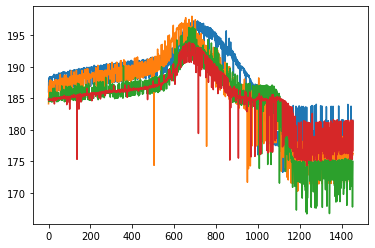

In [99]:
import matplotlib.pyplot as plt

plt.plot(np.array(gray_values)[:,0])
plt.plot(np.array(gray_values)[:,4])
plt.plot(np.array(gray_values)[:,19])
plt.plot(np.array(gray_values)[:,24])

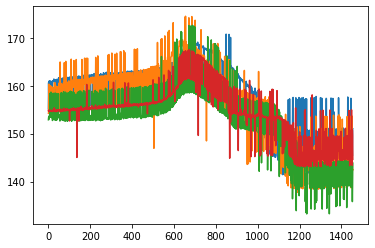

In [101]:
plt.plot(np.array(gray_values)[:,0])
plt.plot(np.array(gray_values)[:,4])
plt.plot(np.array(gray_values)[:,19])
plt.plot(np.array(gray_values)[:,24])